<a href="https://colab.research.google.com/github/sarvesvy/Databyte-task/blob/main/DatabyteCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Configure Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 2. Download the exact Microsoft Cats vs Dogs dataset
!kaggle datasets download -d shaunthesheep/microsoft-catsvsdogs-dataset

# 3. Unzip silently
!unzip -q microsoft-catsvsdogs-dataset.zip -d /content/cats_dogs_dataset

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/shaunthesheep/microsoft-catsvsdogs-dataset
License(s): other
100% 788M/788M [00:06<00:00, 131MB/s] 



In [ ]:
import os
import time
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [ ]:
#we are using external device to store and run it
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu' )
print(f"Using device: {device}")

Using device: cpu


In [ ]:
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
DATAPATH = "/content/cats_dogs_dataset/PetImages"

class Cleandata(Dataset):
  def __init__(self , image_paths , labels , transform=None):
    self.image_paths=image_paths
    self.labels=labels
    self.transform=transform

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, index):
    img_path=self.image_paths[index]
    label=self.labels[index]
    img=Image.open(img_path).convert('RGB') #coversion of image to rgb

    if self.transform:
        img = self.transform(img)

    return img, label

def preprocess(base_dir):
    valid_paths = []
    labels = []
    classes = {'Cat': 0, 'Dog': 1}

    print("Cleaning and verifying dataset files...")
    for class_name, label in classes.items():
        folder = os.path.join(base_dir, class_name)
        if not os.path.exists(folder):
            continue

        for fname in os.listdir(folder):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue

            img_path = os.path.join(folder, fname)

            # Verify file isn't corrupted
            try:
                with Image.open(img_path) as img:
                    img.verify()  # Check if image file is intact
                valid_paths.append(img_path)
                labels.append(label)
            except Exception:
                continue  # Skip corrupted image silently

    print(f"Verified {len(valid_paths)} valid images.")
    return valid_paths, labels

# Load valid image paths & create train/val splits
paths, labels = preprocess(DATAPATH)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    paths, labels, test_size=0.2, random_state=42, stratify=labels
)


Cleaning and verifying dataset files...


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Verified 24998 valid images.


In [ ]:
#data transform and augumentation
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),                # 50% chance horizontal flip
    transforms.RandomRotation(degrees=15),                 # Rotate ±15 degrees
    transforms.ColorJitter(brightness=0.2, contrast=0.2), # brightness variations
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = Cleandata(train_paths, train_labels, transform=train_transform)
test_dataset = Cleandata(val_paths, val_labels, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

class_names = ['Cat', 'Dog']


In [ ]:
#cnn
class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # we need thre layers where the out channels are being doubled
        # ( inchannels , out channels , kernel size, padding)
        self.conv1 = nn.Conv2d(3,16,3,1)
        self.conv2 = nn.Conv2d(16,32,3,1)
        self.conv3 = nn.Conv2d(32,64,3,1)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        self.fc1 = nn.Linear(64 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 2)

        self.dropout = nn.Dropout(p=0.3)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2, 2)

        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2, 2)

        x = F.relu(self.conv3(x))
        x = F.max_pool2d(x, 2, 2)

        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)

        return x

torch.manual_seed(42)
model = CatDogCNN().to(device)

In [ ]:
#Loss Function & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

outputs - [batchsize, num_classes]                                     
criterion(outputs, labesl) -- scaler a tensor = loss                  
loss.items() is a scalar


In [ ]:
epochs=10
train_acc,train_loss,test_acc,test_loss=[],[],[],[]
predictions,targets = [],[]
print('.............Training and validation is starting ........... ')
for epoch in range(epochs):
  model.train()
  current_loss=0.0
  current_true=0
  total=0

  for images, labels in train_loader: # input , output
    images,labels=images.to(device),labels.to(device)

    optimizer.zero_grad()
    outputs=model(images)
    loss=criterion(outputs,labels)
    loss.backward()
    optimizer.step()

    current_loss = current_loss +loss.item()*images.size(0)
    values, pred = torch.max(outputs, 1)
    current_true += (pred==labels).sum().item()
    total += labels.size(0)

  epoch_train_loss = current_loss / total
  epoch_train_acc = (current_true / total) * 100
  train_loss.append(epoch_train_loss)
  train_acc.append(epoch_train_acc)

  model.eval()
  current_loss=0.0
  current_true=0
  total=0

  with torch.no_grad():
    for images, labels in test_loader:
      images, labels=images.to(device), labels.to(device)
      outputs=model(images)
      loss=criterion(outputs, labels)

      current_loss = current_loss + loss.item()*images.size(0)
      values, pred = torch.max(outputs,1)
      current_true = current_true + (pred==labels).sum().item()
      total=total + len(labels)
      # for output
      predictions.extend(pred.cpu().numpy())
      targets.extend(labels.numpy())


  epoch_test_loss = current_loss / total
  epoch_test_acc = (current_true / total) * 100
  test_loss.append(epoch_test_loss)
  test_acc.append(epoch_test_acc)

  print(f"currently running Epochs {epoch+1}/(epochs)")
  print(f"Train Loss: {epoch_train_loss:.4f} - Train Acc: {epoch_train_acc:.2f}% | "
        f"Val Loss: {epoch_test_loss:.4f} - Val Acc: {epoch_test_acc:.2f}%")
predictions=np.array(predictions)
targets=np.array(targets)

.............Training and validation is starting ........... 


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


currently running Epochs 0.0
Train Loss: 0.4404 - Train Acc: 79.77% | Val Loss: 0.4139 - Val Acc: 81.40%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


currently running Epochs 0.09090909090909091
Train Loss: 0.4146 - Train Acc: 81.43% | Val Loss: 0.3804 - Val Acc: 83.24%


...

currently running Epochs 0.6363636363636364
Train Loss: 0.3128 - Train Acc: 86.62% | Val Loss: 0.3070 - Val Acc: 86.80%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


currently running Epochs 0.7272727272727273
Train Loss: 0.3040 - Train Acc: 87.07% | Val Loss: 0.2857 - Val Acc: 87.98%


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


currently running Epochs 0.8181818181818182
Train Loss: 0.2898 - Train Acc: 87.80% | Val Loss: 0.2701 - Val Acc: 88.64%


In [ ]:
images.shape

torch.Size([8, 3, 128, 128])

****************************************
FINAL TEST ACCURACY: 85.86%
****************************************

--- Confusion Matrix ---

 Pred Cat  Pred Dog
Actual Cat:  21282    3718    
Actual Dog:  3352     21648   

-------------------- Classification Report ----------------------------
              precision    recall  f1-score   support

         Cat       0.86      0.85      0.86     25000
         Dog       0.85      0.87      0.86     25000

    accuracy                           0.86     50000
   macro avg       0.86      0.86      0.86     50000
weighted avg       0.86      0.86      0.86     50000

-----------------------------------------------------------------------


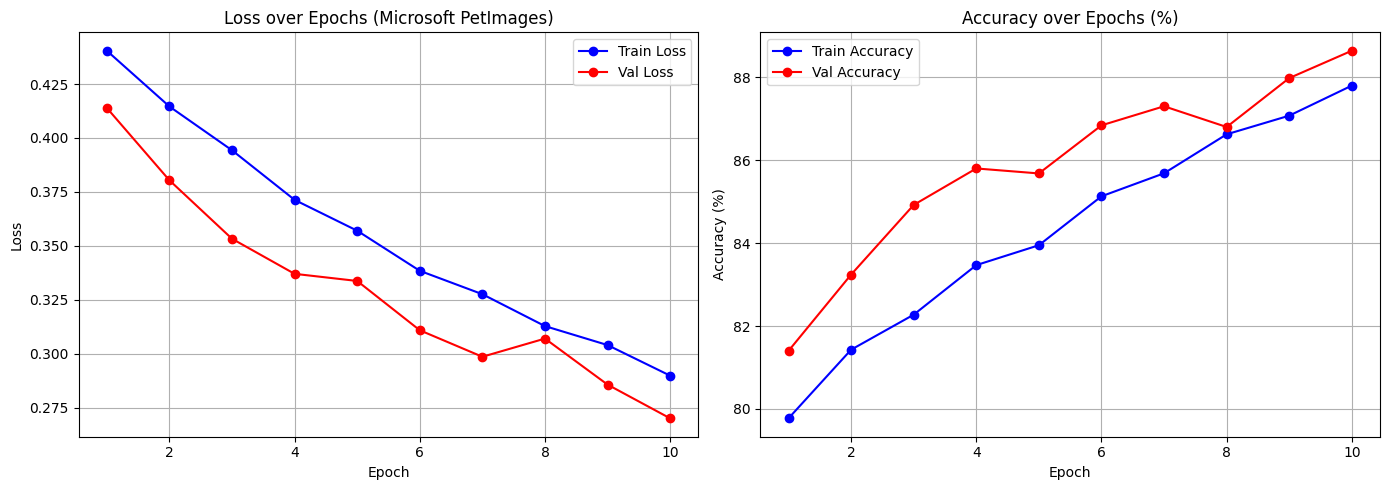

In [ ]:
'''
predictions,targets = [],[]
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        predictions.extend(preds.cpu().numpy())
        targets.extend(labels.numpy())

predictions=np.array(predictions)
targets=np.array(targets)
'''

# Final Accuracy
Accuracy=np.mean(predictions==targets)*100
print("*"*40)
print(f"FINAL TEST ACCURACY: {Accuracy:.2f}%")
print("*"*40)

#Confusion Matrix
CM=confusion_matrix(targets, predictions)
print("\n--- Confusion Matrix ---")
print("\n Pred Cat  Pred Dog")
print(f"Actual Cat:  {CM[0][0]:<8} {CM[0][1]:<8}")
print(f"Actual Dog:  {CM[1][0]:<8} {CM[1][1]:<8}\n")

# 3. Classification Report
report=classification_report(targets , predictions, target_names=class_names)
print("-------------------- Classification Report ----------------------------")
print(report)
print('-----------------------------------------------------------------------')


fig , (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot Loss
ax1.plot(range(1, epochs + 1), train_loss, label='Train Loss', color='blue', marker='o')
ax1.plot(range(1, epochs + 1), test_loss, label='Val Loss', color='red', marker='o')
ax1.set_title('Loss over Epochs (Microsoft PetImages)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Plot Accuracy
ax2.plot(range(1, epochs + 1), train_acc, label='Train Accuracy', color='blue', marker='o')
ax2.plot(range(1, epochs + 1), test_acc, label='Val Accuracy', color='red', marker='o')
ax2.set_title('Accuracy over Epochs (%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()